# STUDY FOR EXAM 2
- Diff in Diff
- Event Study
- Time Series
- IV
- RV
- OLS
- Choropleths

### Diff in Diff
 - How much change happens when we change a variable
    - Do free lunches improve school outcomes?
    - Suppose Barzil has a free lunch program in 2009
    - Compare test scores in brazil b/w 2008-2010
    - D1 would be score diff. between 08-10
    - D1 = D of prog + D of trend
- Now, lets say we do the same but in Rio instead of Sao Paolo
    - Rio = D2 
    - difference- in difference would be D1 - D2 
    - D3 is difference of 2010 Brazil and 2010 Sao Paolo
    ---
- ### When to use Diff in Diff
    - You Want to evaluate a program or treatment
    - You have tratment and control groups
    - You Observe them before and after
    ----
- #### BUT!!!
    - Treatment is not random 
    - Other things were happening while program was in effect (AKA a soccer tournamanet in 2008)
    - YOu cant control for all the potential cofounders
- #### Key Assumption:
    - Trend in control group approximates what would have happened in the treatment group in the absence of treatment.

#### Now, Lets Apply. Did Eliminating coapy increase visits to Physicians?

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import os
os.chdir('/Users/jackson/Documents/ECON570')

In [4]:
file = 'data/femaleVisitsToPhysician.csv'
df = pd.read_csv(file)

df['visits'] = df.consultations #rename to consultations
df.head()

,Unnamed: 0,year,age,sex,consultations,population,perCapita,visits
0,4,2006,1,f,67194.0,28221.0,2.380993,67194.0
1,7,2006,2,f,49802.0,28361.0,1.756003,49802.0
2,10,2006,3,f,42741.0,27899.0,1.531990,42741.0
3,13,2006,4,f,36555.0,28420.0,1.286242,36555.0
4,16,2006,5,f,33319.0,29479.0,1.130262,33319.0


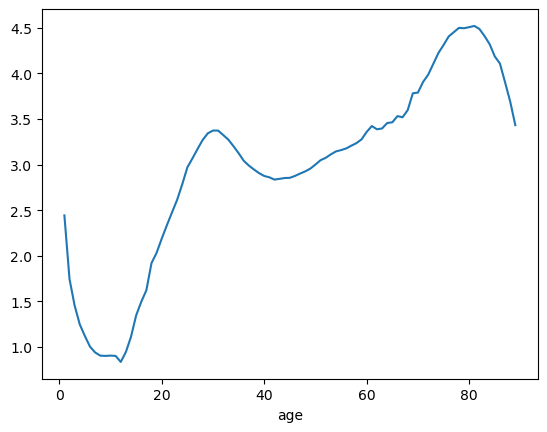

In [5]:
df.groupby('age')['perCapita'].mean().plot();

In [9]:
df14 = df.query('age == 14') # only 14 year olds
df14

,Unnamed: 0,year,age,sex,consultations,population,perCapita,visits
13,43,2006,14,f,29129.0,30927.0,0.941863,29129.0
102,399,2007,14,f,29563.0,30464.0,0.970424,29563.0
191,752,2008,14,f,29848.0,30578.0,0.976127,29848.0
280,1100,2009,14,f,31140.0,30755.0,1.012518,31140.0
369,1439,2010,14,f,36296.0,30983.0,1.171481,36296.0
458,1774,2011,14,f,39799.0,31522.0,1.262579,39799.0
547,2087,2012,14,f,38880.0,31080.0,1.250965,38880.0
636,2369,2013,14,f,39609.0,30559.0,1.296148,39609.0


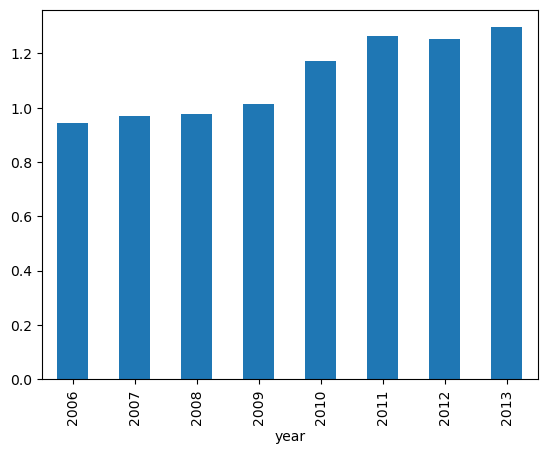

In [10]:
df14.set_index('year').perCapita.plot.bar();

In [15]:
df2 = df.query('age ==14 or age == 25') # only 14 and 25 year olds

In [16]:
df2 = df2[['year', 'age', 'perCapita']]
df2.head()

,year,age,perCapita
13,2006,14,0.941863
24,2006,25,2.724488
102,2007,14,0.970424
113,2007,25,2.883638
191,2008,14,0.976127


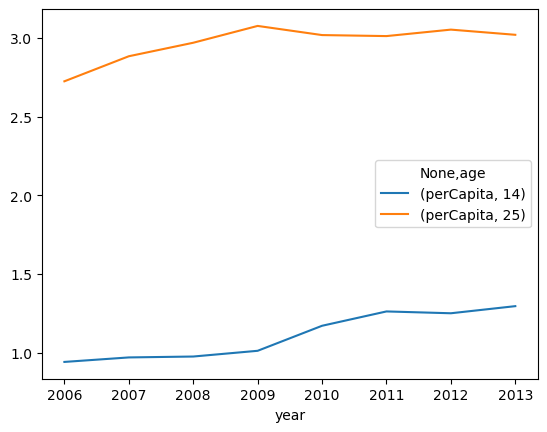

In [19]:
df2.set_index(['year', 'age']).unstack('age').plot();

In [22]:
df14and25 = df2.set_index(['year', 'age']).unstack('age') #compare development of 14 adn 25 year olds
df14and25

perCapita          
age         14        25
year                    
2006  0.941863  2.724488
2007  0.970424  2.883638
2008  0.976127  2.969386
2009  1.012518  3.076277
2010  1.171481  3.018165
2011  1.262579  3.011706
2012  1.250965  3.052795
2013  1.296148  3.019887

In [23]:
df14and25 ['copay'] = 0

In [25]:
df14and25['copay'] = df14and25.copay.where(df14and25.index<2010, 1)
df14and25

perCapita           copay
age         14        25      
year                          
2006  0.941863  2.724488     0
2007  0.970424  2.883638     0
2008  0.976127  2.969386     0
2009  1.012518  3.076277     0
2010  1.171481  3.018165     1
2011  1.262579  3.011706     1
2012  1.250965  3.052795     1
2013  1.296148  3.019887     1

In [26]:
result = df14and25.groupby('copay').mean()
result

perCapita          
age          14        25
copay                    
0      0.975233  2.913447
1      1.245293  3.025638

In [29]:
result.columns = ['age_14', 'age_25']
result

,age_14,age_25
copay,,
0,0.975233,2.913447
1,1.245293,3.025638


In [32]:
result['age_25'] - result['age_14']

copay
0    1.938214
1    1.780345
dtype: float64

### Now we run diff-in-diff regression

In [34]:
df2

,year,age,perCapita
13,2006,14,0.941863
24,2006,25,2.724488
102,2007,14,0.970424
113,2007,25,2.883638
191,2008,14,0.976127
202,2008,25,2.969386
280,2009,14,1.012518
291,2009,25,3.076277
369,2010,14,1.171481
380,2010,25,3.018165


In [ ]:
df2['copay'] = 0 
df2['copay'] = df2.copay.where(df2.year < 2010, 1)
df2

,year,age,perCapita,copay
13,2006,14,0.941863,0
24,2006,25,2.724488,0
102,2007,14,0.970424,0
113,2007,25,2.883638,0
191,2008,14,0.976127,0
202,2008,25,2.969386,0
280,2009,14,1.012518,0
291,2009,25,3.076277,0
369,2010,14,1.171481,1
380,2010,25,3.018165,1


In [36]:
df2['age_14'] = np.where(df2.age == 14, 1, 0)
df2

,year,age,perCapita,copay,age_14
13,2006,14,0.941863,0,1
24,2006,25,2.724488,0,0
102,2007,14,0.970424,0,1
113,2007,25,2.883638,0,0
191,2008,14,0.976127,0,1
202,2008,25,2.969386,0,0
280,2009,14,1.012518,0,1
291,2009,25,3.076277,0,0
369,2010,14,1.171481,1,1
380,2010,25,3.018165,1,0


In [49]:
# outcome = treated dummy + after intervention + affected by * after dummy (+other variables)

# visits = being_14 + after2010 + being_14 * after2010

model = 'perCapita ~ age_14 + copay + copay * age_14 + year'

In [50]:
mod = smf.ols(formula = model, data = df2)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              perCapita   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     987.2
Date:                Wed, 05 Nov 2025   Prob (F-statistic):           5.65e-14
Time:                        14:05:44   Log-Likelihood:                 25.410
No. Observations:                  16   AIC:                            -40.82
Df Residuals:                      11   BIC:                            -36.96
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -85.7891     26.764     -3.205   

/opt/anaconda3/envs/econ570/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


coefficient of copay went up by .1579
not really significant
added year 